In [ ]:
ls


EuroSAT_RGB.zip  sample_data/


In [ ]:
!ls -lh

total 91M
-rw-r--r-- 1 root root  91M May 10 13:00 EuroSAT_RGB.zip
drwxr-xr-x 1 root root 4.0K May  6 13:29 sample_data


In [ ]:
!unzip EuroSAT_RGB.zip

Streaming output truncated to the last 5000 lines.
  inflating: EuroSAT_RGB/Residential/Residential_489.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_1573.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_270.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_516.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2683.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_502.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2697.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_264.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2867.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2873.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_258.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2126.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_1349.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2640.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2898.jpg  
  inflating: EuroSAT_RGB/Residential/Residential_2654.j

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/EuroSAT_RGB',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 21600 images belonging to 10 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    '/content/EuroSAT_RGB',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 5400 images belonging to 10 classes.


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 141s 206ms/step - accuracy: 0.5169 - loss: 1.2579 - val_accuracy: 0.6667 - val_loss: 0.9199
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.7185 - loss: 0.7777 - val_accuracy: 0.7157 - val_loss: 0.7600
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.7713 - loss: 0.6398 - val_accuracy: 0.7856 - val_loss: 0.6083
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.8061 - loss: 0.5458 - val_accuracy: 0.7967 - val_loss: 0.5796
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 136s 202ms/step - accuracy: 0.8311 - loss: 0.4823 - val_accuracy: 0.8067 - val_loss: 0.5505


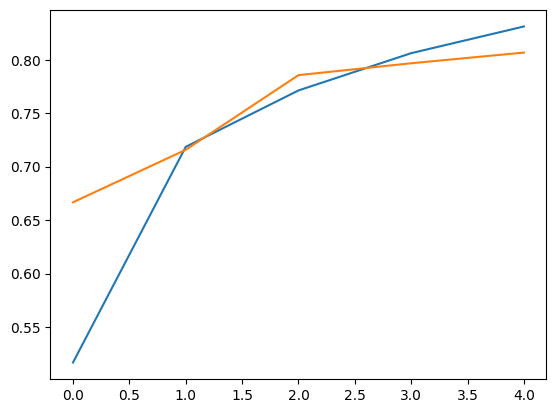

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
import os

dataset_path="/content/EuroSAT_RGB"

annual_crop_path=os.path.join(dataset_path,"AnnualCrop")

count=len(os.listdir(annual_crop_path))

print("Total Annual Crop Images:",count)

Total Annual Crop Images: 3000


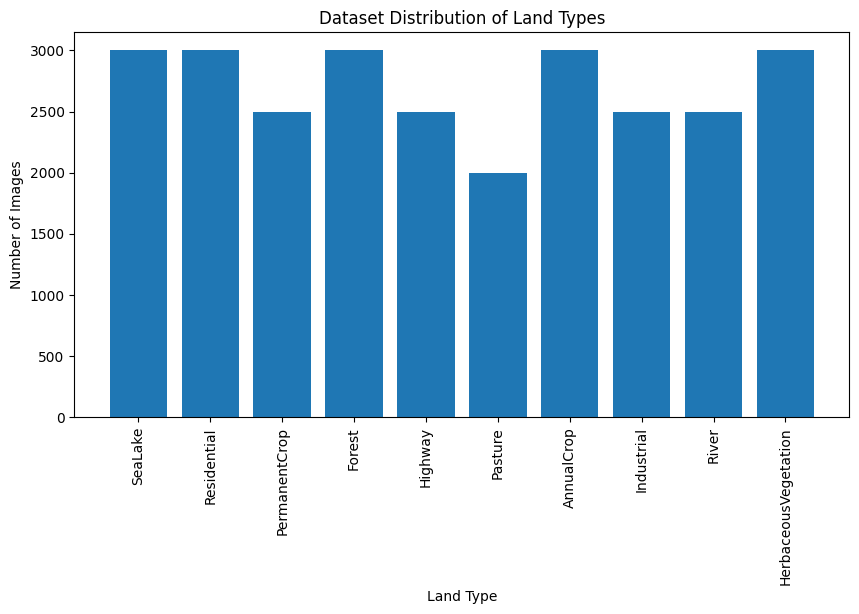

In [ ]:
classes=os.listdir(dataset_path)
counts=[]

for c in classes:
    counts.append(len(os.listdir(os.path.join(dataset_path,c))))

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(classes,counts)

plt.xlabel("Land Type")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution of Land Types")
plt.xticks(rotation=90)

plt.show()

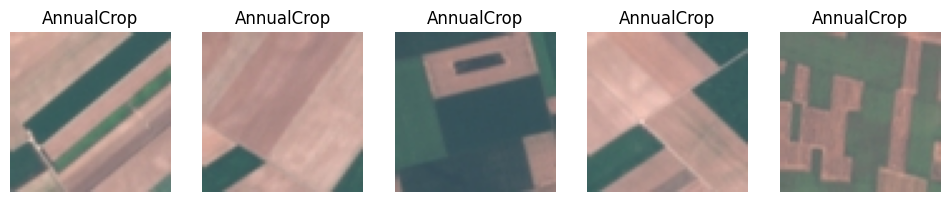

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

files=os.listdir(annual_crop_path)

plt.figure(figsize=(12,6))

for i in range(5):
    img=random.choice(files)
    img_path=os.path.join(annual_crop_path,img)

    image=Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("AnnualCrop")

plt.show()

In [ ]:
predictions_count = validation_generator.n
print(predictions_count)

5400


In [ ]:
{
 'AnnualCrop':45,
 'Forest':30,
 'River':15
}

{'AnnualCrop': 45, 'Forest': 30, 'River': 15}

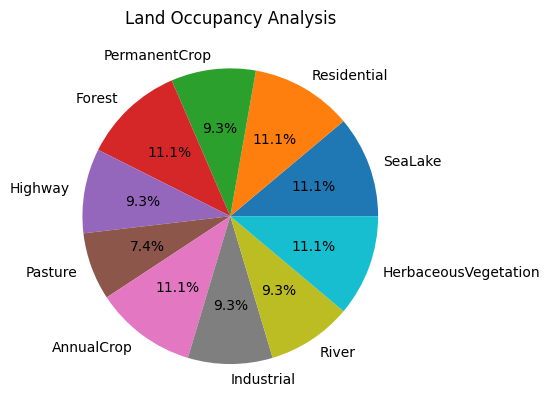

In [ ]:
labels=classes
sizes=counts

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Land Occupancy Analysis")
plt.show()

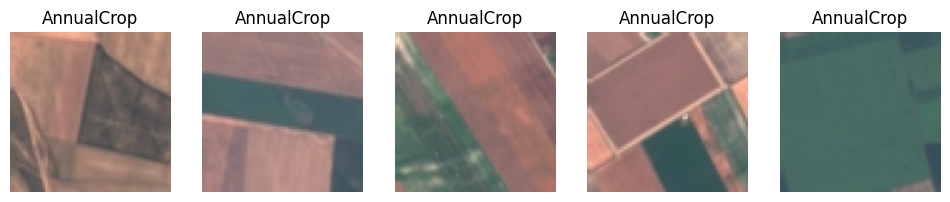

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

annual_crop_path=os.path.join(dataset_path,"AnnualCrop")

files=os.listdir(annual_crop_path)

plt.figure(figsize=(12,6))

for i in range(5):
    img=random.choice(files)
    img_path=os.path.join(annual_crop_path,img)

    image=Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("AnnualCrop")

plt.show()

In [ ]:
import os
from PIL import Image
import math

# Folder path
folder_path = "/content/EuroSAT_RGB/AnnualCrop"

# Get all image files
image_files = os.listdir(folder_path)

print("Total images:", len(image_files))

Total images: 3000


In [ ]:
thumbnail_size = (16,16)

images = []

for file in image_files:
    img_path = os.path.join(folder_path,file)

    img = Image.open(img_path)
    img = img.resize(thumbnail_size)

    images.append(img)

In [ ]:
num_images = len(images)

grid_size = math.ceil(math.sqrt(num_images))

print("Grid size:", grid_size, "x", grid_size)

Grid size: 55 x 55


In [ ]:
mosaic_width = grid_size * thumbnail_size[0]
mosaic_height = grid_size * thumbnail_size[1]

mosaic = Image.new('RGB',(mosaic_width,mosaic_height))

In [ ]:
for index,img in enumerate(images):
    x = (index % grid_size) * thumbnail_size[0]
    y = (index // grid_size) * thumbnail_size[1]

    mosaic.paste(img,(x,y))

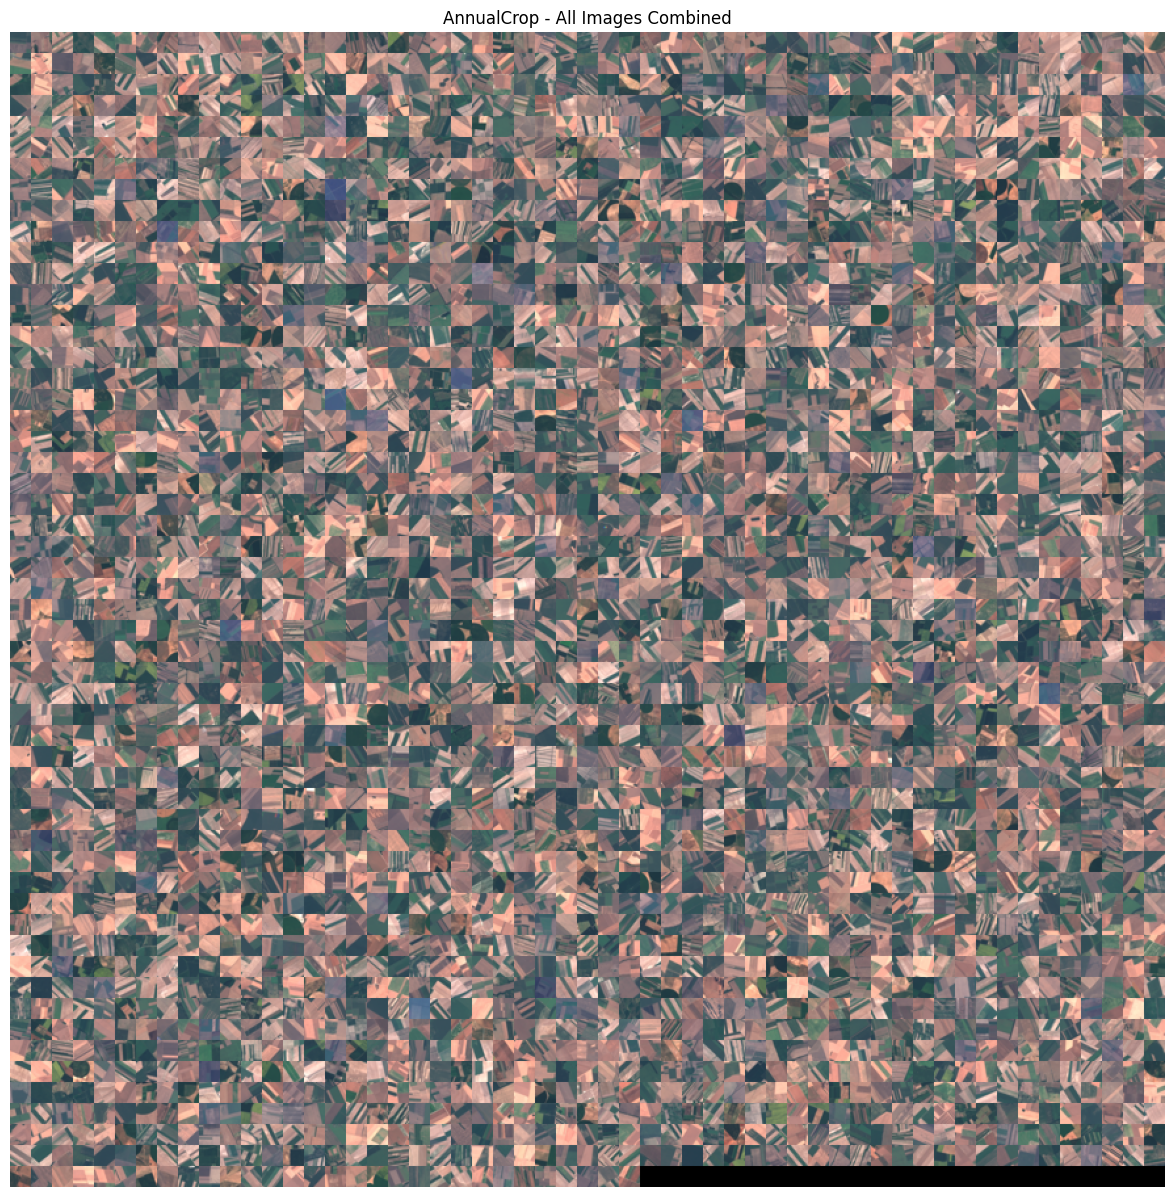

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))
plt.imshow(mosaic)
plt.axis("off")
plt.title("AnnualCrop - All Images Combined")
plt.show()

In [ ]:
mosaic.save("annual_crop_mosaic.png")

In [ ]:
import os
from PIL import Image
import math
folder_path = '/content/EuroSAT_RGB/Forest'
image_files = os.listdir(folder_path)
print("Total images:", len(image_files))


Total images: 3000


In [ ]:
thumbnail_size = (16,16)

images = []

for file in image_files:
    img_path = os.path.join(folder_path,file)

    img = Image.open(img_path)
    img = img.resize(thumbnail_size)

    images.append(img)

In [ ]:
num_images = len(images)

grid_size = math.ceil(math.sqrt(num_images))

print("Grid size:", grid_size, "x", grid_size)

Grid size: 55 x 55


In [ ]:
mosaic_width = grid_size * thumbnail_size[0]
mosaic_height = grid_size * thumbnail_size[1]

mosaic = Image.new('RGB',(mosaic_width,mosaic_height))

In [ ]:
for index,img in enumerate(images):
    x = (index % grid_size) * thumbnail_size[0]
    y = (index // grid_size) * thumbnail_size[1]

    mosaic.paste(img,(x,y))

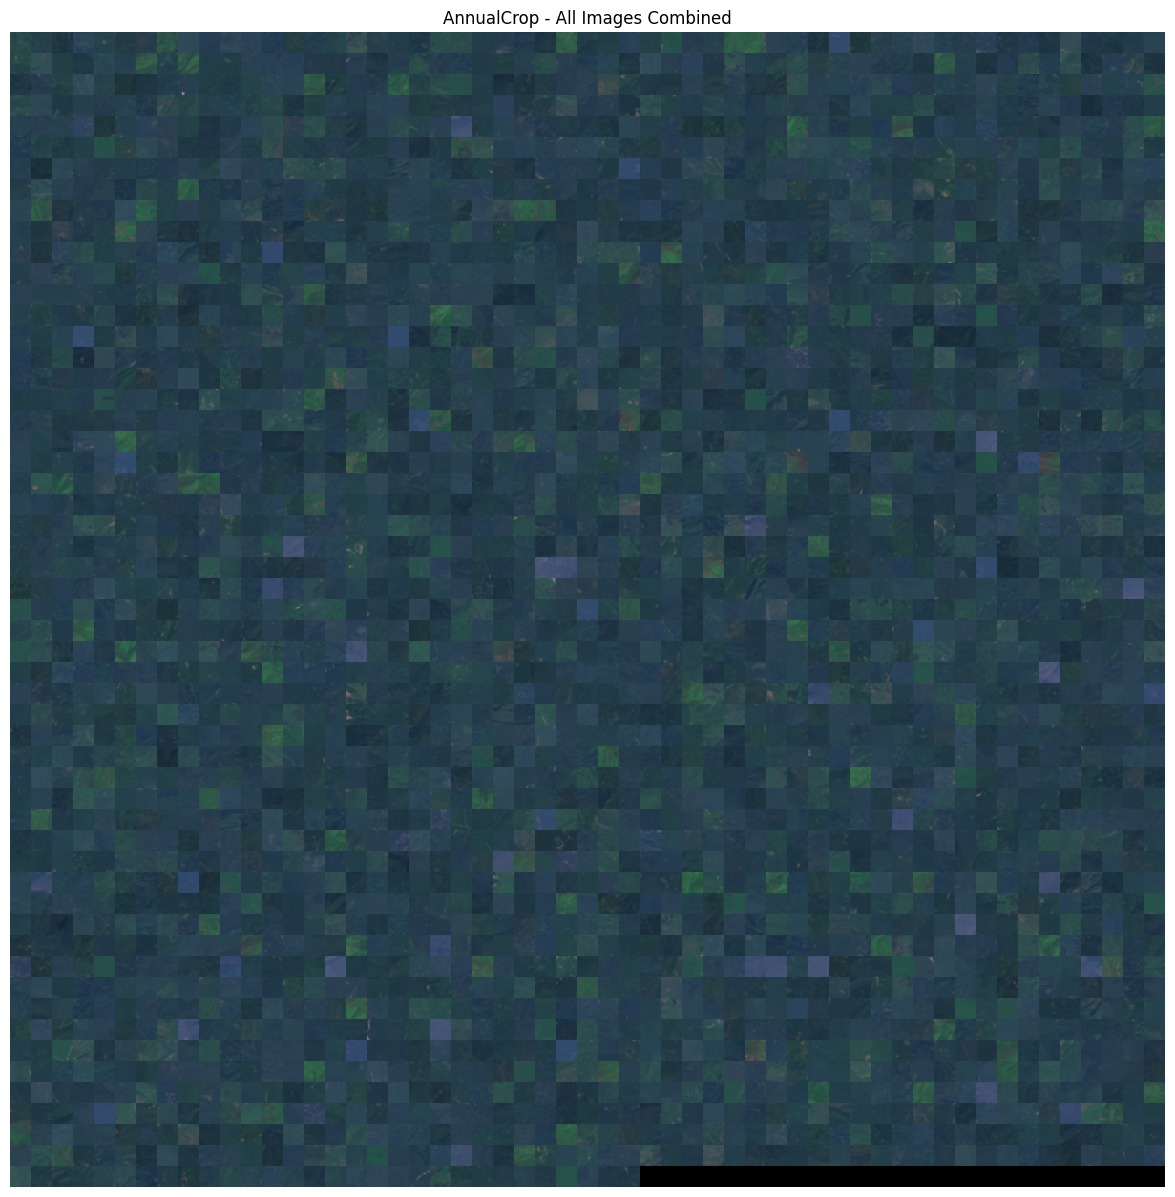

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,15))
plt.imshow(mosaic)
plt.axis("off")
plt.title("AnnualCrop - All Images Combined")
plt.show()

In [ ]:
mosaic.save("Forest.png")